NJN_BestModel_FullPack_EffNet_Full_vs_PCAHybrid_V2

In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm tensorflow joblib

In [2]:
import os, glob, random, json, joblib
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix,
    brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from google.colab import drive

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATASET_PATH = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
all_imgs = []

for ext in img_exts:
    all_imgs += glob.glob(os.path.join(DATASET_PATH, "**", ext), recursive=True)

print("Total images found:", len(all_imgs))
print("Sample paths:", all_imgs[:5])

Total images found: 760
Sample paths: ['/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1024).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (566).jpg']


In [6]:
# Labeling
def infer_label_from_path(p):
    lp = p.lower()

    pos_keys = ["jaundice", "icteric", "positive", "pos", "case", "patient", "affected", "yellow"]
    neg_keys = ["normal", "control", "negative", "neg", "healthy", "non"]

    if any(k in lp for k in pos_keys):
        return 1
    if any(k in lp for k in neg_keys):
        return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p, l) for p, l in pairs if l is not None]

imgs = [p for p, l in pairs]
y_all = np.array([l for p, l in pairs])

print("Total labeled:", len(pairs))
print("Class counts (0=Normal, 1=Jaundice):", np.bincount(y_all))
print("Example:", pairs[:3])

Total labeled: 760
Class counts (0=Normal, 1=Jaundice): [560 200]
Example: [('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', 0)]


In [7]:
# Final ROI functions
# ----------------------------
# Final Forehead ROI
# ----------------------------
def get_forehead_box(img_bgr):
    h, w = img_bgr.shape[:2]

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    candidates = []
    min_area = max(300, int(0.002 * h * w))
    for i in range(1, num_labels):
        x, y, bw, bh, area = stats[i]
        if area >= min_area:
            candidates.append((i, x, y, bw, bh, area))

    if candidates:
        candidates = sorted(candidates, key=lambda t: (t[2], -t[5]))
        _, x, y, bw, bh, area = candidates[0]

        pad_x = int(0.05 * bw)
        pad_y = int(0.05 * bh)
        x = max(0, x - pad_x)
        y = max(0, y - pad_y)
        bw = min(w - x, bw + 2 * pad_x)
        bh = min(h - y, bh + 2 * pad_y)

        x1 = max(0, x + int(0.28 * bw))
        x2 = min(w, x + int(0.68 * bw))
        y1 = max(0, y + int(0.05 * bh))
        y2 = min(h, y + int(0.15 * bh))
    else:
        x1 = int(0.34 * w)
        x2 = int(0.60 * w)
        y1 = int(0.08 * h)
        y2 = int(0.15 * h)

    if (x2 - x1) < 12 or (y2 - y1) < 12:
        x1 = int(0.34 * w)
        x2 = int(0.60 * w)
        y1 = int(0.08 * h)
        y2 = int(0.15 * h)

    return x1, y1, x2, y2, mask


def extract_forehead_roi(img_bgr):
    x1, y1, x2, y2, _ = get_forehead_box(img_bgr)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


# ----------------------------
# Final Chest ROI
# ----------------------------
def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.28 * w)
    x2 = int(0.78 * w)
    y1 = int(0.50 * h)
    y2 = int(0.72 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


# ----------------------------
# Abdomen ROI
# ----------------------------
def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.60 * h)
    y2 = int(0.92 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

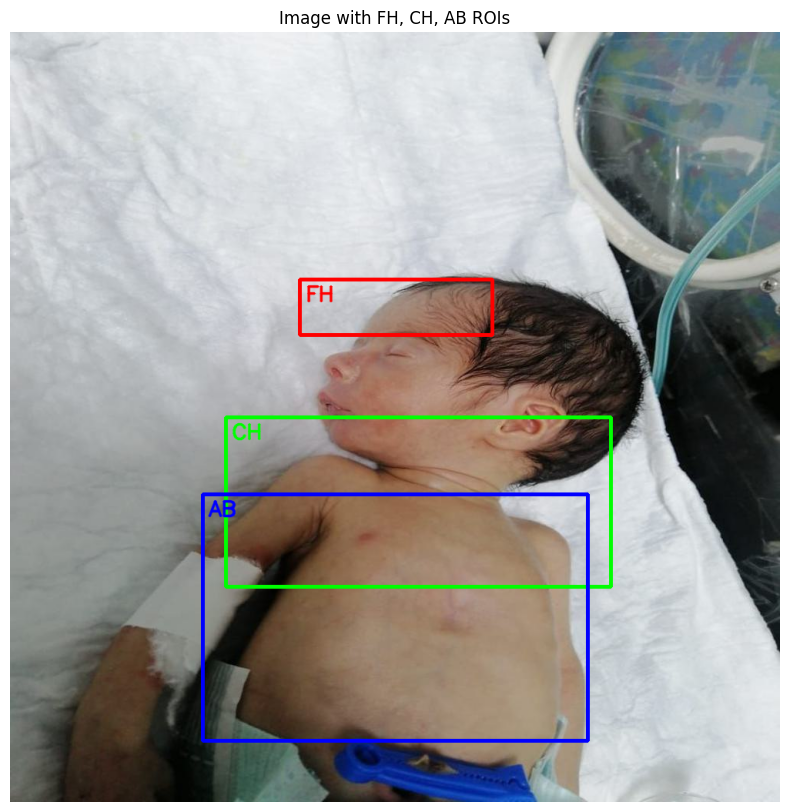

In [8]:
# ROI preview with FH / CH / AB labels
sample_path = imgs[0]
img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

vis = img_rgb.copy()

# FH
x1f, y1f, x2f, y2f, _ = get_forehead_box(img)
cv2.rectangle(vis, (x1f, y1f), (x2f, y2f), (255, 0, 0), 3)
cv2.putText(vis, "FH", (x1f + 8, y1f + 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2, cv2.LINE_AA)

# CH
h, w = img.shape[:2]
x1c, x2c = int(0.28 * w), int(0.78 * w)
y1c, y2c = int(0.50 * h), int(0.72 * h)
cv2.rectangle(vis, (x1c, y1c), (x2c, y2c), (0, 255, 0), 3)
cv2.putText(vis, "CH", (x1c + 8, y1c + 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2, cv2.LINE_AA)

# AB
x1a, x2a = int(0.25 * w), int(0.75 * w)
y1a, y2a = int(0.60 * h), int(0.92 * h)
cv2.rectangle(vis, (x1a, y1a), (x2a, y2a), (0, 0, 255), 3)
cv2.putText(vis, "AB", (x1a + 8, y1a + 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2, cv2.LINE_AA)

plt.figure(figsize=(10, 10))
plt.imshow(vis)
plt.title("Image with FH, CH, AB ROIs")
plt.axis("off")
plt.show()

In [9]:
# Classical preprocessing + feature extraction
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)

    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0

    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))

    out = cv2.merge([b, g, r])
    return np.clip(out, 0, 255).astype(np.uint8)


def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    L2 = clahe.apply(L)

    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)


def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr


def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)

    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)

    return mask


def masked_stats(channel, mask):
    vals = channel[mask == 255].astype(np.float32)

    if vals.size < 30:
        return (np.nan,) * 6

    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )


def extract_classical_features(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)

    if np.sum(mask == 255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8) * 255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:, :, 0]
    G = roi_rgb[:, :, 1]
    B = roi_rgb[:, :, 2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))
    rg_balance = float((Rm - Gm) / (Rm + Gm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom)
    g_ch = float(Gm / denom)
    b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask == 255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0, 180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:, :, 0]
    a = lab[:, :, 1]
    b = lab[:, :, 2]

    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask == 255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "RG_balance": rg_balance,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }

    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

In [10]:
# EfficientNetB0 embedding extractor
IMG_SIZE = 224

eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
eff.trainable = False


def roi_to_tensor(roi_bgr):
    roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    roi = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    x = roi.astype(np.float32)
    x = preprocess_input(x)
    return x


def get_eff_embedding(img_bgr, roi_fn):
    roi = roi_fn(img_bgr)
    if roi is None:
        return None

    x = roi_to_tensor(roi)
    emb = eff(np.expand_dims(x, 0), training=False).numpy().ravel()
    return emb

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# Build dataset: classical + deep embeddings aligned
rows = []
FH_list, CH_list, AB_list = [], [], []
failed = 0

for p, label in tqdm(pairs, desc="Building EffNet Full-vs-PCAHybrid V2 dataset"):
    img = cv2.imread(p)

    if img is None:
        failed += 1
        continue

    fh = extract_forehead_roi(img)
    ch = extract_chest_roi(img)
    ab = extract_abdomen_roi(img)

    if fh is None or ch is None or ab is None:
        failed += 1
        continue

    try:
        fh_feat = extract_classical_features(fh)
        ch_feat = extract_classical_features(ch)
        ab_feat = extract_classical_features(ab)

        e_fh = get_eff_embedding(img, extract_forehead_roi)
        e_ch = get_eff_embedding(img, extract_chest_roi)
        e_ab = get_eff_embedding(img, extract_abdomen_roi)
    except:
        failed += 1
        continue

    if (e_fh is None) or (e_ch is None) or (e_ab is None):
        failed += 1
        continue

    row = {"path": p, "label": int(label)}
    row.update({f"FH_{k}": v for k, v in fh_feat.items()})
    row.update({f"CH_{k}": v for k, v in ch_feat.items()})
    row.update({f"AB_{k}": v for k, v in ab_feat.items()})

    rows.append(row)
    FH_list.append(e_fh)
    CH_list.append(e_ch)
    AB_list.append(e_ab)

X_classical_df = pd.DataFrame(rows)
FH_mat = np.vstack(FH_list)
CH_mat = np.vstack(CH_list)
AB_mat = np.vstack(AB_list)

print("Classical DF:", X_classical_df.shape, "Failed:", failed)
print("Embeddings:", FH_mat.shape, CH_mat.shape, AB_mat.shape)
print(X_classical_df["label"].value_counts())

Building EffNet Full-vs-PCAHybrid V2 dataset: 100%|██████████| 760/760 [27:24<00:00,  2.16s/it]

Classical DF: (760, 83) Failed: 0
Embeddings: (760, 1280) (760, 1280) (760, 1280)
label
0    560
1    200
Name: count, dtype: int64


In [12]:
# Same split indices for both proposed models
y = X_classical_df["label"].astype(int).values
idx_all = np.arange(len(y))

train_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train = y[train_idx]
y_test = y[test_idx]

print("Train/Test:", len(train_idx), len(test_idx))
print("Test distribution:", np.bincount(y_test))

Train/Test: 608 152
Test distribution: [112  40]


In [13]:
# Train-only imputer + train-only PCA
# Classical features
classical_cols = [c for c in X_classical_df.columns if c not in ["path", "label"]]
Xc_train_df = X_classical_df.iloc[train_idx][classical_cols]
Xc_test_df = X_classical_df.iloc[test_idx][classical_cols]

imputer = SimpleImputer(strategy="median")
Xc_train = imputer.fit_transform(Xc_train_df)
Xc_test = imputer.transform(Xc_test_df)

# Deep features
deep_all = np.hstack([FH_mat, CH_mat, AB_mat])  # (N, 3840)
deep_train = deep_all[train_idx]
deep_test = deep_all[test_idx]

# PCA-Hybrid uses PCA on train only
pca_dim = 128
pca = PCA(n_components=pca_dim, random_state=42)
deep_train_pca = pca.fit_transform(deep_train)
deep_test_pca = pca.transform(deep_test)

# Final matrices
X_full_train = np.hstack([Xc_train, deep_train])
X_full_test = np.hstack([Xc_test, deep_test])

X_pca_train = np.hstack([Xc_train, deep_train_pca])
X_pca_test = np.hstack([Xc_test, deep_test_pca])

print("Full Hybrid train/test:", X_full_train.shape, X_full_test.shape)
print("PCA-Hybrid train/test :", X_pca_train.shape, X_pca_test.shape)
print("PCA explained variance sum:", pca.explained_variance_ratio_.sum())

Full Hybrid train/test: (608, 3921) (152, 3921)
PCA-Hybrid train/test : (608, 209) (152, 209)
PCA explained variance sum: 0.74555826


In [14]:
# Train-only PCA sweep (64/128/256)
dims = [64, 128, 256]
sweep_rows = []

for d in dims:
    pca_tmp = PCA(n_components=d, random_state=42)
    deep_train_pca_tmp = pca_tmp.fit_transform(deep_train)
    deep_test_pca_tmp = pca_tmp.transform(deep_test)

    X_train_tmp = np.hstack([Xc_train, deep_train_pca_tmp])

    svm_tmp = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ])

    # simple train-set CV style approximation can be added later;
    # for V2 we just store explained variance on training data
    sweep_rows.append({
        "pca_dim": d,
        "explained_var_sum": float(pca_tmp.explained_variance_ratio_.sum())
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df)

   pca_dim  explained_var_sum
0       64           0.607815
1      128           0.745558
2      256           0.878520


In [15]:
# Train Full Hybrid + PCA-Hybrid models
svm_full = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

svm_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

svm_full.fit(X_full_train, y_train)
svm_pca.fit(X_pca_train, y_train)

prob_full = svm_full.predict_proba(X_full_test)[:, 1]
prob_pca = svm_pca.predict_proba(X_pca_test)[:, 1]

print("Full Hybrid Test AUC:", roc_auc_score(y_test, prob_full))
print("PCA-Hybrid Test AUC :", roc_auc_score(y_test, prob_pca))

Full Hybrid Test AUC: 0.8752232142857143
PCA-Hybrid Test AUC : 0.8506696428571429


In [16]:
# Exact bootstrap helpers (AUC CI + Brier CI)
def bootstrap_auc_ci(y_true, prob, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    boot = []

    y_true = np.array(y_true)
    prob = np.array(prob)

    for _ in tqdm(range(n_boot), desc="Bootstrap AUC"):
        idx = rng.randint(0, len(prob), len(prob))
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot.append(roc_auc_score(y_true[idx], prob[idx]))

    boot = np.array(boot)
    low = np.percentile(boot, 2.5)
    high = np.percentile(boot, 97.5)
    return float(low), float(high), boot


def bootstrap_brier_ci(y_true, prob, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    boot = []

    y_true = np.array(y_true)
    prob = np.array(prob)

    for _ in tqdm(range(n_boot), desc="Bootstrap Brier"):
        idx = rng.randint(0, len(prob), len(prob))
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot.append(brier_score_loss(y_true[idx], prob[idx]))

    boot = np.array(boot)
    low = np.percentile(boot, 2.5)
    high = np.percentile(boot, 97.5)
    return float(low), float(high), boot

In [17]:
# Full evaluation pack with exact Brier CI
def full_eval_pack(y_true, prob, title="Model", n_boot=2000, seed=42):
    y_true = np.array(y_true)
    prob = np.array(prob)

    # ROC
    fpr, tpr, thr = roc_curve(y_true, prob)
    rocA = auc(fpr, tpr)

    # PR
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, prob)
    ap = average_precision_score(y_true, prob)

    # Calibration / Brier
    brier = brier_score_loss(y_true, prob)
    frac_pos, mean_pred = calibration_curve(y_true, prob, n_bins=10)

    # Youden threshold
    j = tpr - fpr
    idx = np.argmax(j)
    youden_thr = thr[idx]

    pred_y = (prob >= youden_thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred_y).ravel()

    acc = accuracy_score(y_true, pred_y)
    prec = precision_score(y_true, pred_y, zero_division=0)
    rec = recall_score(y_true, pred_y, zero_division=0)
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, pred_y, zero_division=0)

    # Bootstrap AUC CI
    auc_low, auc_high, boot_auc = bootstrap_auc_ci(y_true, prob, n_boot=n_boot, seed=seed)

    # Bootstrap Brier CI
    brier_low, brier_high, boot_brier = bootstrap_brier_ci(y_true, prob, n_boot=n_boot, seed=seed)

    # ROC
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC={rocA:.3f}")
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.scatter([fpr[idx]], [tpr[idx]], s=60)
    plt.annotate(
        f"Youden thr={youden_thr:.3f}\nFPR={fpr[idx]:.3f}, TPR={tpr[idx]:.3f}",
        (fpr[idx], tpr[idx]),
        textcoords="offset points",
        xytext=(10, -15),
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
    )
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"ROC — {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # PR
    plt.figure(figsize=(6, 4))
    plt.plot(rec_curve, prec_curve, linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR — {title} (AP={ap:.3f})")
    plt.grid(alpha=0.3)
    plt.show()

    # Calibration
    plt.figure(figsize=(6, 4))
    plt.plot(mean_pred, frac_pos, "o-", label="Model")
    plt.plot([0, 1], [0, 1], "--", label="Perfect")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration — {title} (Brier={brier:.3f})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Probability histogram
    plt.figure(figsize=(6, 4))
    plt.hist(prob[y_true == 0], bins=15, alpha=0.6, label="Normal (0)")
    plt.hist(prob[y_true == 1], bins=15, alpha=0.6, label="Jaundice (1)")
    plt.title(f"Probability Distribution — {title}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # AUC bootstrap hist
    plt.figure(figsize=(6, 4))
    plt.hist(boot_auc, bins=30, alpha=0.75)
    plt.axvline(auc_low, linestyle="--", label="2.5%")
    plt.axvline(auc_high, linestyle="--", label="97.5%")
    plt.axvline(np.mean(boot_auc), label="Mean")
    plt.title(f"Bootstrap AUC Distribution — {title}")
    plt.xlabel("AUC")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    # Brier bootstrap hist
    plt.figure(figsize=(6, 4))
    plt.hist(boot_brier, bins=30, alpha=0.75)
    plt.axvline(brier_low, linestyle="--", label="2.5%")
    plt.axvline(brier_high, linestyle="--", label="97.5%")
    plt.axvline(np.mean(boot_brier), label="Mean")
    plt.title(f"Bootstrap Brier Distribution — {title}")
    plt.xlabel("Brier Score")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    print(f"\n===== {title} — Table 1 =====")
    print(f"Test AUC: {rocA:.4f}")
    print(f"95% CI (AUC): [{auc_low:.4f}, {auc_high:.4f}]")
    print(f"PR AP: {ap:.4f}")
    print(f"Brier score: {brier:.4f}")
    print(f"95% CI (Brier): [{brier_low:.4f}, {brier_high:.4f}]")

    print(f"\n===== {title} — Table 2 (Youden J) =====")
    print("Threshold rule: Youden J")
    print(f"Threshold: {youden_thr:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"Specificity: {spec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Confusion matrix: [[{tn}, {fp}], [{fn}, {tp}]]")

    return {
        "AUC": float(rocA),
        "AUC_CI_low": float(auc_low),
        "AUC_CI_high": float(auc_high),
        "AP": float(ap),
        "Brier": float(brier),
        "Brier_CI_low": float(brier_low),
        "Brier_CI_high": float(brier_high),
        "Threshold": float(youden_thr),
        "Accuracy": float(acc),
        "Precision": float(prec),
        "Recall": float(rec),
        "Specificity": float(spec),
        "F1": float(f1),
        "Confusion_Matrix": [[int(tn), int(fp)], [int(fn), int(tp)]]
    }

Bootstrap Brier: 100%|██████████| 2000/2000 [00:01<00:00, 1451.34it/s]


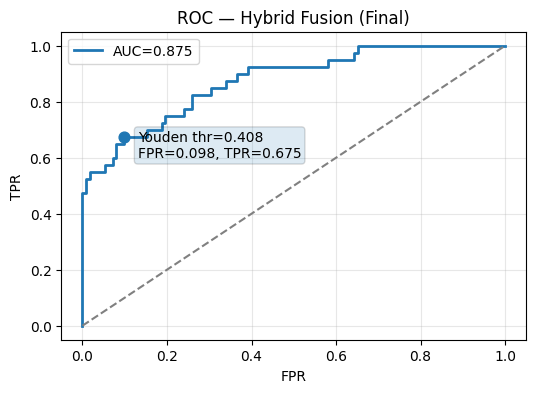

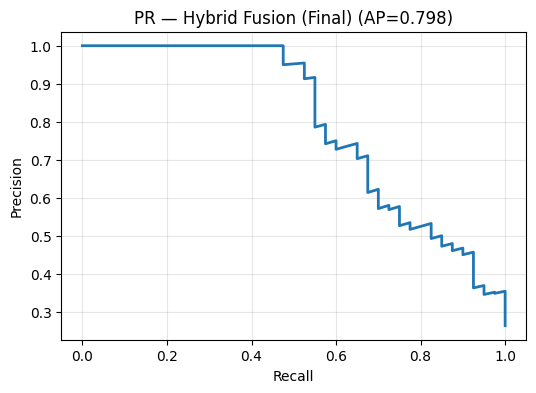

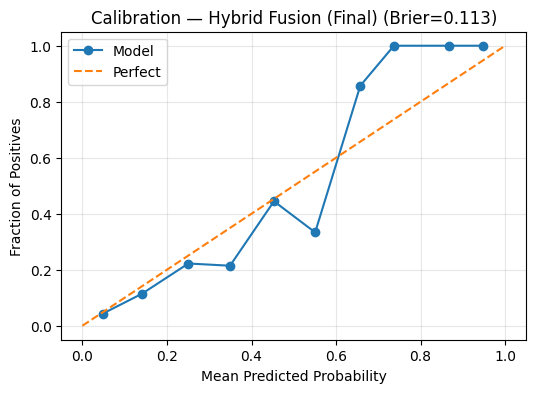

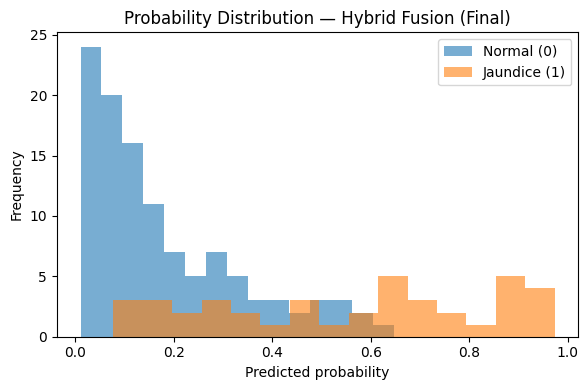

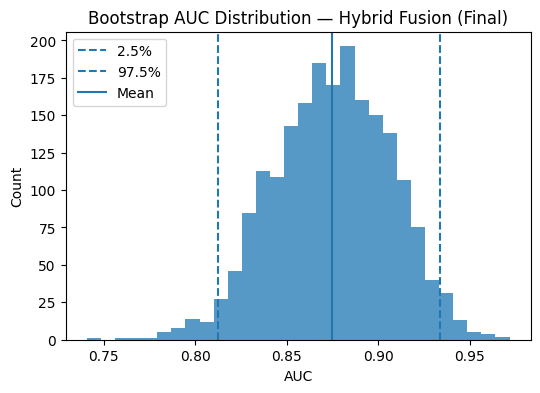

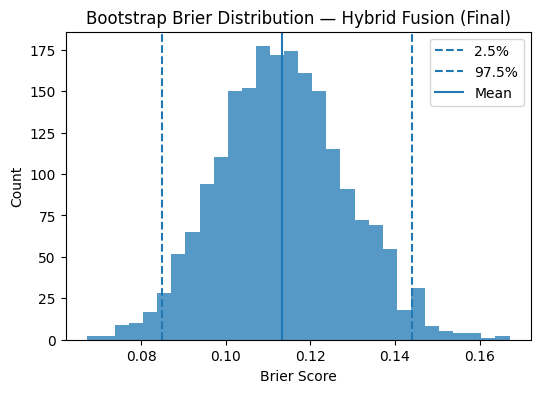


===== Hybrid Fusion (Final) — Table 1 =====
Test AUC: 0.8752
95% CI (AUC): [0.8125, 0.9335]
PR AP: 0.7976
Brier score: 0.1134
95% CI (Brier): [0.0850, 0.1440]

===== Hybrid Fusion (Final) — Table 2 (Youden J) =====
Threshold rule: Youden J
Threshold: 0.4077
Accuracy: 0.8421
Precision: 0.7105
Recall: 0.6750
Specificity: 0.9018
F1-score: 0.6923
Confusion matrix: [[101, 11], [13, 27]]


Bootstrap Brier: 100%|██████████| 2000/2000 [00:01<00:00, 1763.11it/s]


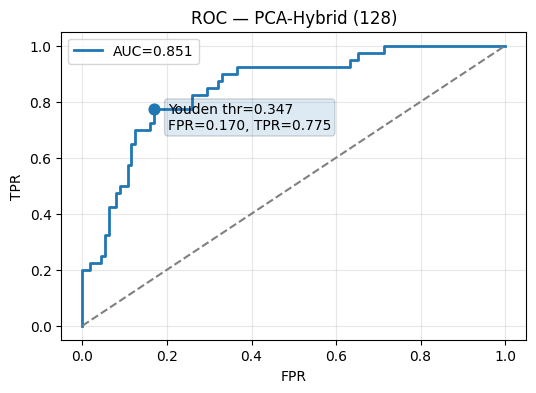

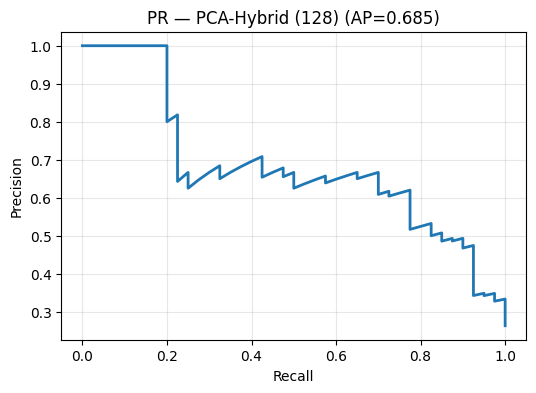

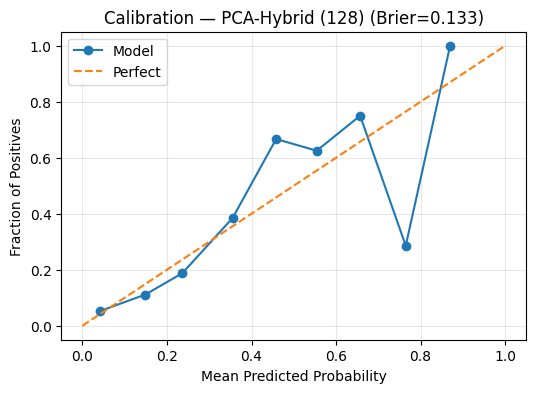

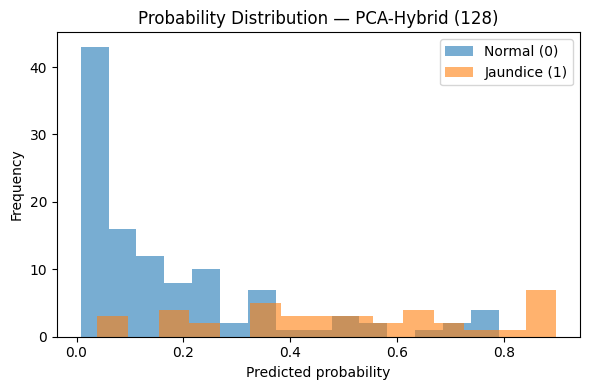

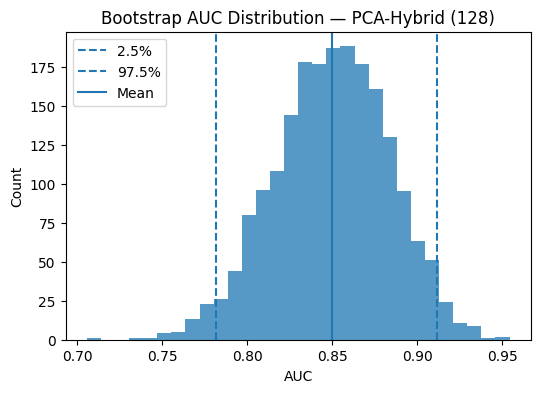

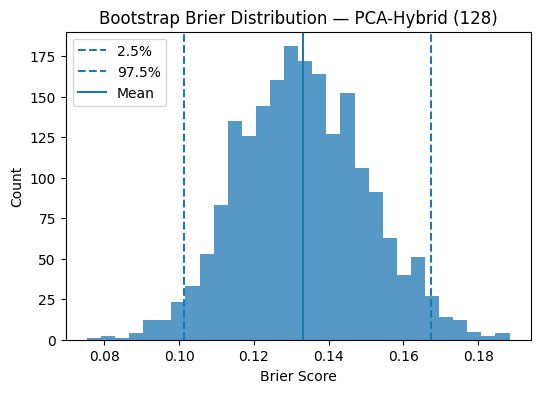


===== PCA-Hybrid (128) — Table 1 =====
Test AUC: 0.8507
95% CI (AUC): [0.7814, 0.9116]
PR AP: 0.6848
Brier score: 0.1328
95% CI (Brier): [0.1013, 0.1674]

===== PCA-Hybrid (128) — Table 2 (Youden J) =====
Threshold rule: Youden J
Threshold: 0.3468
Accuracy: 0.8158
Precision: 0.6200
Recall: 0.7750
Specificity: 0.8304
F1-score: 0.6889
Confusion matrix: [[93, 19], [9, 31]]

=== Quick Comparison Summary ===
Hybrid Fusion (Final): {'AUC': 0.8752232142857143, 'AUC_CI_low': 0.8125474987974989, 'AUC_CI_high': 0.9335148627184026, 'AP': 0.797597268030855, 'Brier': 0.11338035554029743, 'Brier_CI_low': 0.08504705628823372, 'Brier_CI_high': 0.14402474376073546, 'Threshold': 0.40767850434053177, 'Accuracy': 0.8421052631578947, 'Precision': 0.7105263157894737, 'Recall': 0.675, 'Specificity': 0.9017857142857143, 'F1': 0.6923076923076923, 'Confusion_Matrix': [[101, 11], [13, 27]]}
PCA-Hybrid (128): {'AUC': 0.8506696428571429, 'AUC_CI_low': 0.7813611581486043, 'AUC_CI_high': 0.9115998948940098, 'AP': 0

In [18]:
# Run full evaluation for both proposed models
res_full = full_eval_pack(
    y_test, prob_full,
    title="Hybrid Fusion (Final)",
    n_boot=2000,
    seed=42
)

res_pca = full_eval_pack(
    y_test, prob_pca,
    title="PCA-Hybrid (128)",
    n_boot=2000,
    seed=42
)

print("\n=== Quick Comparison Summary ===")
print("Hybrid Fusion (Final):", res_full)
print("PCA-Hybrid (128):", res_pca)

In [19]:
# Final compact comparison table
comparison_df = pd.DataFrame([
    {
        "Model": "Hybrid Fusion (Final)",
        "Test AUC": round(res_full["AUC"], 4),
        "95% CI (AUC)": f'[{res_full["AUC_CI_low"]:.4f}, {res_full["AUC_CI_high"]:.4f}]',
        "PR AP": round(res_full["AP"], 4),
        "Brier Score": round(res_full["Brier"], 4),
        "95% CI (Brier)": f'[{res_full["Brier_CI_low"]:.4f}, {res_full["Brier_CI_high"]:.4f}]',
        "Threshold": round(res_full["Threshold"], 4),
        "Accuracy": round(res_full["Accuracy"], 4),
        "Precision": round(res_full["Precision"], 4),
        "Recall": round(res_full["Recall"], 4),
        "Specificity": round(res_full["Specificity"], 4),
        "F1-score": round(res_full["F1"], 4),
        "Confusion Matrix": str(res_full["Confusion_Matrix"])
    },
    {
        "Model": "PCA-Hybrid (128)",
        "Test AUC": round(res_pca["AUC"], 4),
        "95% CI (AUC)": f'[{res_pca["AUC_CI_low"]:.4f}, {res_pca["AUC_CI_high"]:.4f}]',
        "PR AP": round(res_pca["AP"], 4),
        "Brier Score": round(res_pca["Brier"], 4),
        "95% CI (Brier)": f'[{res_pca["Brier_CI_low"]:.4f}, {res_pca["Brier_CI_high"]:.4f}]',
        "Threshold": round(res_pca["Threshold"], 4),
        "Accuracy": round(res_pca["Accuracy"], 4),
        "Precision": round(res_pca["Precision"], 4),
        "Recall": round(res_pca["Recall"], 4),
        "Specificity": round(res_pca["Specificity"], 4),
        "F1-score": round(res_pca["F1"], 4),
        "Confusion Matrix": str(res_pca["Confusion_Matrix"])
    }
])

comparison_df

,Model,Test AUC,95% CI (AUC),PR AP,Brier Score,95% CI (Brier),Threshold,Accuracy,Precision,Recall,Specificity,F1-score,Confusion Matrix
0,Hybrid Fusion (Final),0.8752,"[0.8125, 0.9335]",0.7976,0.1134,"[0.0850, 0.1440]",0.4077,0.8421,0.7105,0.675,0.9018,0.6923,"[[101, 11], [13, 27]]"
1,PCA-Hybrid (128),0.8507,"[0.7814, 0.9116]",0.6848,0.1328,"[0.1013, 0.1674]",0.3468,0.8158,0.6200,0.775,0.8304,0.6889,"[[93, 19], [9, 31]]"


In [20]:
# Save CSVs
comparison_df.to_csv("effnet_full_vs_pcahybrid_v2_summary.csv", index=False)
print("Saved: effnet_full_vs_pcahybrid_v2_summary.csv")

Saved: effnet_full_vs_pcahybrid_v2_summary.csv


In [21]:
# Save development bundle (for backend / future deployment)
bundle = {
    "classical_feature_columns": classical_cols,
    "imputer": imputer,
    "pca_dim": pca_dim,
    "pca_model": pca,
    "svm_full": svm_full,
    "svm_pca": svm_pca,
    "roi_config": {
        "forehead": "improved dynamic heuristic",
        "chest": {"x1": 0.28, "x2": 0.78, "y1": 0.50, "y2": 0.72},
        "abdomen": {"x1": 0.25, "x2": 0.75, "y1": 0.60, "y2": 0.92}
    },
    "model_names": {
        "full": "Hybrid Fusion (Final)",
        "pca": "PCA-Hybrid (128)"
    }
}

joblib.dump(bundle, "effnet_full_vs_pcahybrid_v2_bundle.joblib")
print("Saved: effnet_full_vs_pcahybrid_v2_bundle.joblib")

Saved: effnet_full_vs_pcahybrid_v2_bundle.joblib


In [22]:
# Optional save EfficientNet feature extractor
eff.save("effnetb0_feature_extractor_v2.keras")
print("Saved: effnetb0_feature_extractor_v2.keras")

Saved: effnetb0_feature_extractor_v2.keras


In [23]:
# Single-image inference function (development-ready)
def build_classical_row_from_image(img_bgr):
    fh = extract_forehead_roi(img_bgr)
    ch = extract_chest_roi(img_bgr)
    ab = extract_abdomen_roi(img_bgr)

    if fh is None or ch is None or ab is None:
        return None

    fh_feat = extract_classical_features(fh)
    ch_feat = extract_classical_features(ch)
    ab_feat = extract_classical_features(ab)

    row = {}
    row.update({f"FH_{k}": v for k, v in fh_feat.items()})
    row.update({f"CH_{k}": v for k, v in ch_feat.items()})
    row.update({f"AB_{k}": v for k, v in ab_feat.items()})

    return row


def predict_single_image(image_path, mode="pca"):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not read image.")

    # Classical
    row = build_classical_row_from_image(img)
    if row is None:
        raise ValueError("ROI extraction failed.")

    x_classical_df = pd.DataFrame([row])[classical_cols]
    x_classical = imputer.transform(x_classical_df)

    # Deep
    e_fh = get_eff_embedding(img, extract_forehead_roi)
    e_ch = get_eff_embedding(img, extract_chest_roi)
    e_ab = get_eff_embedding(img, extract_abdomen_roi)

    if (e_fh is None) or (e_ch is None) or (e_ab is None):
        raise ValueError("Embedding extraction failed.")

    deep = np.hstack([e_fh, e_ch, e_ab]).reshape(1, -1)

    if mode == "full":
        X = np.hstack([x_classical, deep])
        prob = svm_full.predict_proba(X)[:, 1][0]
        model_name = "Hybrid Fusion (Final)"
        threshold = res_full["Threshold"]
    else:
        deep_pca_1 = pca.transform(deep)
        X = np.hstack([x_classical, deep_pca_1])
        prob = svm_pca.predict_proba(X)[:, 1][0]
        model_name = "PCA-Hybrid (128)"
        threshold = res_pca["Threshold"]

    pred = int(prob >= threshold)

    return {
        "model": model_name,
        "threshold": float(threshold),
        "probability_jaundice": float(prob),
        "predicted_label": int(pred),
        "predicted_class_name": "Jaundice" if pred == 1 else "Normal"
    }

In [24]:
# Test single-image inference
test_result_full = predict_single_image(imgs[0], mode="full")
test_result_pca = predict_single_image(imgs[0], mode="pca")

print("Full model result:", test_result_full)
print("PCA model result :", test_result_pca)

Full model result: {'model': 'Hybrid Fusion (Final)', 'threshold': 0.40767850434053177, 'probability_jaundice': 0.03006689597269752, 'predicted_label': 0, 'predicted_class_name': 'Normal'}
PCA model result : {'model': 'PCA-Hybrid (128)', 'threshold': 0.3467715896204612, 'probability_jaundice': 0.06002907091652667, 'predicted_label': 0, 'predicted_class_name': 'Normal'}


In [25]:
# Save lightweight deployment metadata JSON
deployment_meta = {
    "preferred_deployment_model": "PCA-Hybrid (128)",
    "reason": "lightweight proposed model for future real-time deployment",
    "pca_dim": pca_dim,
    "classical_feature_count": len(classical_cols),
    "deep_embedding_dim_before_pca": int(deep_train.shape[1]),
    "deep_embedding_dim_after_pca": int(pca_dim),
    "full_model_threshold_youden": float(res_full["Threshold"]),
    "pca_model_threshold_youden": float(res_pca["Threshold"]),
    "full_model_auc": float(res_full["AUC"]),
    "pca_model_auc": float(res_pca["AUC"])
}

with open("deployment_meta_v2.json", "w") as f:
    json.dump(deployment_meta, f, indent=2)

print("Saved: deployment_meta_v2.json")

Saved: deployment_meta_v2.json
